In [50]:
import warnings
warnings.filterwarnings("ignore")

import time
import os
from pathlib import Path
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(precision = 2, suppress = True)

In [3]:
ROOT_DIR = Path().cwd().parents[0]
os.chdir(ROOT_DIR)

from src.config import Processed_data
os.chdir(ROOT_DIR/Processed_data)

C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\IndiaKart-E-Commerce-Analytics-Project


In [4]:
orders_data = pd.read_csv("orders.csv", parse_dates = ["order_date", "delivered_date"])
orders_data.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,0,20486.45,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaT,1,App
1,ORD000002,CUST04232,2023-10-16,05:32:00,Delivered,Ludhiana,Punjab,387852,254478.01,41599.80,0,19338.79,254478.01,UPI,DTDC,TRK272838570,2023-10-19,0,Website
2,ORD000003,CUST08078,2023-10-08,12:32:00,Cancelled,Meerut,Uttar Pradesh,294014,32557.06,3562.92,0,696.86,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaT,0,App
3,ORD000004,CUST09612,2023-10-02,08:05:00,Delivered,Nashik,Maharashtra,626047,24836.94,3092.88,0,4029.94,24836.94,UPI,DTDC,TRK289792017,2023-09-10,0,Mobile Web
4,ORD000005,CUST03065,2024-06-15,20:19:00,Delivered,Moradabad,Uttar Pradesh,409210,156689.29,25092.36,0,7805.07,156689.29,UPI,Ecom Express,TRK978240041,2024-06-22,0,App


## **1) KPI: Gross Marchandise Value (GMV)**
### **KPI Purpose:** Total business size including cancellations.
### **KPI Definition:** Sum of all final_amount (all statuses)

### **Data Sources:**
- orders Table
### **Exspected Output:** a single kpi value(Float) represeting Total business size including cancellations.

In [5]:
display(f"Average Order Value (AOV) : {round(float(orders_data.final_amount.sum()),2)}")

'Average Order Value (AOV) : 3147385544.58'

## **2) KPI: Net Revenue**
### **KPI Purpose:** Actual money earned by the platform.
### **KPI Definition:** Sum of final_amount where status = Delivered

### **Data Sources:**
- orders Table
### **Exspected Output:** a single kpi value(Float) represeting Actual money earned by the platform.

In [6]:
delivered_orders = orders_data[orders_data["status"] == "Delivered"]
display(f"Net Revenue : {round(float(delivered_orders.final_amount.sum()),2)}")

'Net Revenue : 2053858611.96'

## **3) KPI: Average Order Value (AOV)**
### **KPI Purpose:** Higher AOV = customers buying more per visit.
### **KPI Definition:** Net Revenue / Count of Delivered Orders

### **Data Sources:**
- orders Table
### **Exspected Output:** a single kpi value(Float) represeting AOV of platform.

In [7]:
aov = float(delivered_orders.final_amount.sum() / len(delivered_orders))
display(f"Average Order Value (AOV) : {round(aov,2)}")

'Average Order Value (AOV) : 63197.59'

## **4) KPI: Cancellation Rate**
### **KPI Purpose:** Target < 10%. Higher = lost revenue.
### **KPI Definition:** (Cancelled Orders / Total Orders) × 100

### **Data Sources:**
- orders Table
### **Exspected Output:** a single kpi value(Float) represeting Cancellation Rate Percentage of platform.

In [8]:
cancelled_orders = orders_data[orders_data["status"] == "Cancelled"]
cancellation_rate = float(len(cancelled_orders) / len(orders_data))
display(f"Cancellation Rate : {round(cancellation_rate,2)}")

'Cancellation Rate : 0.12'

## **5) KPI: Return Rate**
### **KPI Purpose:** Target < 8%. Higher = product quality issues.
### **KPI Definition:** (Return records / Delivered Orders) × 100

### **Data Sources:**
- orders & returns Tables
### **Exspected Output:** a single kpi value(Float) represeting Return Rate Percentage of platform.

In [9]:
returns_data = pd.read_csv("returns.csv")
returns_data.head(3)

,return_id,order_id,customer_id,return_date,reason,return_amount,refund_status,refund_date,return_condition,remarks
0,RET00001,ORD000015,CUST05470,2024-12-23,Size Issue,24167.33,Pending,2024-12-30,Damaged,Customer initiated return within 7 day window
1,RET00002,ORD000017,CUST07581,2023-01-11,Defective Product,11698.27,Refunded,2023-06-11,Damaged,Customer initiated return within 7 day window
2,RET00003,ORD000038,CUST05691,2025-01-05,Wrong Product Delivered,11147.74,Refunded,2025-06-05,Damaged,Customer initiated return within 7 day window


In [10]:
orders_returns_data = returns_data.merge(orders_data , on = "order_id", how = "right")

In [11]:
orders_returns_data.head()

,return_id,order_id,customer_id_x,return_date,reason,return_amount,refund_status,refund_date,return_condition,remarks,...,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,NaN,ORD000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16364.64,0,20486.45,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaT,1,App
1,NaN,ORD000002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41599.80,0,19338.79,254478.01,UPI,DTDC,TRK272838570,2023-10-19,0,Website
2,RET03934,ORD000003,CUST08078,2023-12-10,Quality Issue,32557.06,Refunded,2023-10-16,Good,Customer initiated return within 7 day window,...,3562.92,0,696.86,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaT,0,App
3,NaN,ORD000004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3092.88,0,4029.94,24836.94,UPI,DTDC,TRK289792017,2023-09-10,0,Mobile Web
4,NaN,ORD000005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25092.36,0,7805.07,156689.29,UPI,Ecom Express,TRK978240041,2024-06-22,0,App


In [12]:
total_returned_orders = len(orders_returns_data[~orders_returns_data.return_id.isnull()])
total_delivered_order = len(orders_returns_data[orders_returns_data["status"] == "Delivered"])
return_rate = float((total_returned_orders / total_delivered_order)*100)
display(f"Return Rate : {round(return_rate,2)}")

'Return Rate : 30.77'

## **6) KPI: Customer Lifetime Value (CLV)**
### **KPI Purpose:** Premium segment should be 3x Regular.
### **KPI Definition:** Avg total_spent per customer segment

### **Data Sources:**
- customers table
### **Exspected Output:** a single kpi value(Float) represeting Customer Lifetime Value (CLV) of platform.

In [13]:
customers_data = pd.read_csv("customers.csv", parse_dates = ["registration_date"])
customers_data.head()

,customer_id,first_name,last_name,email,phone,city,state,pincode,gender,age,segment,registration_date,last_login_date,is_verified,is_active,total_orders,total_spent
0,CUST00001,Kunal,Gupta,kunal.gupta223@gmail.com,9117912889,Guwahati,Assam,314040,Male,54,New,2024-07-30,2025-10-04,0,1,7,1028341.51
1,CUST00002,Aryan,Gupta,aryan.gupta336@yahoo.in,9271550550,Navi Mumbai,Maharashtra,799535,Female,26,Budget,2023-07-05,2024-03-05,1,1,1,20337.39
2,CUST00003,Akash,Chatterjee,akash.chatterjee584@hotmail.com,9559676548,Surat,Gujarat,738196,Female,24,Regular,2022-05-14,2023-10-31,1,1,7,265688.26
3,CUST00004,Madhuri,Walia,madhuri.walia878@gmail.com,9673322422,Gwalior,Madhya Pradesh,238106,Female,23,Regular,2025-01-21,2025-05-22,1,0,7,173446.94
4,CUST00005,Vishal,Das,vishal.das342@yahoo.in,9920855521,Dhanbad,Jharkhand,783291,Female,59,Regular,2023-06-06,2024-03-29,1,0,4,239808.60


In [14]:
customers_data.segment.unique()

array(['New', 'Budget', 'Regular', 'Premium', 'Inactive'], dtype=object)

In [15]:
avg_total_spend_per_segment = customers_data.groupby("segment")["total_spent"].mean()
avg_total_spend_per_segment

segment
Budget     186178.81
Inactive    32249.08
New        274866.48
Premium    532735.00
Regular    361870.72
Name: total_spent, dtype: float64

## **7) KPI: Month-over-Month Growth**
### **KPI Purpose:** Shows business trajectory.
### **KPI Definition:** ((This Month GMV - Last Month GMV) / Last Month) × 100 

### **Data Sources:**
- orders table
### **Exspected Output:** a single kpi value(Float) represeting Shows business trajectory of platform.

In [16]:
orders_data.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,0,20486.45,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaT,1,App
1,ORD000002,CUST04232,2023-10-16,05:32:00,Delivered,Ludhiana,Punjab,387852,254478.01,41599.80,0,19338.79,254478.01,UPI,DTDC,TRK272838570,2023-10-19,0,Website
2,ORD000003,CUST08078,2023-10-08,12:32:00,Cancelled,Meerut,Uttar Pradesh,294014,32557.06,3562.92,0,696.86,32557.06,Debit Card,Amazon Logistics,TRK338505401,NaT,0,App
3,ORD000004,CUST09612,2023-10-02,08:05:00,Delivered,Nashik,Maharashtra,626047,24836.94,3092.88,0,4029.94,24836.94,UPI,DTDC,TRK289792017,2023-09-10,0,Mobile Web
4,ORD000005,CUST03065,2024-06-15,20:19:00,Delivered,Moradabad,Uttar Pradesh,409210,156689.29,25092.36,0,7805.07,156689.29,UPI,Ecom Express,TRK978240041,2024-06-22,0,App


In [17]:
orders_data.order_date.max()

Timestamp('2025-06-23 00:00:00')

In [18]:
current_month = orders_data.order_date.max().to_period("M")
last_month = current_month - 1
current_month

Period('2025-06', 'M')

In [19]:
last_month

Period('2025-05', 'M')

In [20]:
current_month_data = orders_data[orders_data["order_date"].dt.to_period("M") == current_month]
current_month_data.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
53,ORD000054,CUST03170,2025-06-13,15:16:00,Returned,Raipur,Chhattisgarh,798127,9284.55,720.66,0,558.11,9284.55,UPI,DTDC,TRK239232637,NaT,0,Website
72,ORD000073,CUST09911,2025-06-07,03:59:00,Delivered,Nashik,Maharashtra,754372,10116.05,1633.52,0,1105.47,10116.05,Credit Card,Amazon Logistics,TRK627661645,2025-11-06,0,Mobile Web
103,ORD000104,CUST09905,2025-06-18,03:14:00,Shipped,Guwahati,Assam,388071,7027.54,1055.16,0,33.62,7027.54,Credit Card,XpressBees,TRK700759438,NaT,0,App
124,ORD000125,CUST07342,2025-06-03,18:37:00,Delivered,Solapur,Maharashtra,446364,69804.54,7544.28,0,5410.74,69804.54,UPI,Shadowfax,TRK323205121,2025-05-06,0,App
189,ORD000190,CUST05469,2025-06-20,21:27:00,Delivered,Meerut,Uttar Pradesh,131405,20219.43,859.86,0,2636.43,20219.43,Wallet,Ecom Express,TRK660508582,2025-06-25,0,App


In [21]:
last_month_orders = orders_data[orders_data["order_date"].dt.to_period("M") == last_month]
last_month_orders.head()

,order_id,customer_id,order_date,order_time,status,city,state,pincode,total_amount,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,ORD000001,CUST02946,2025-05-22,17:10:00,Processing,Pune,Maharashtra,300862,100984.19,16364.64,0,20486.45,100984.19,Cash on Delivery,BlueDart,TRK354572763,NaT,1,App
19,ORD000020,CUST00700,2025-05-01,13:49:00,Delivered,Jodhpur,Rajasthan,224095,7324.71,1744.12,0,648.41,7324.71,EMI,XpressBees,TRK520577230,2025-08-05,0,App
34,ORD000035,CUST01370,2025-05-26,17:56:00,Cancelled,Mumbai,Maharashtra,135015,532061.13,82016.52,0,11940.39,532061.13,UPI,DTDC,TRK731489123,NaT,0,App
70,ORD000071,CUST02416,2025-05-23,00:25:00,Delivered,Nashik,Maharashtra,135225,118609.60,19520.10,0,12695.50,118609.60,UPI,XpressBees,TRK601729201,2025-05-27,0,Mobile Web
125,ORD000126,CUST04398,2025-05-12,18:29:00,Delivered,Jabalpur,Madhya Pradesh,288426,36428.70,5246.88,0,5349.18,36428.70,UPI,XpressBees,TRK891823913,2025-05-14,0,Website


In [22]:
last_month_GMV = float(last_month_orders.final_amount.sum())
last_month_GMV

135849393.2

In [23]:
current_month_GMV = float(current_month_data.final_amount.sum())
current_month_GMV

103603347.86

In [24]:
Month_over_Month_Growth = ((current_month_GMV - last_month_GMV) / last_month_GMV)*100
display(f"Month_over_Month_Growth : {round(Month_over_Month_Growth,2)}")

'Month_over_Month_Growth : -23.74'

## **8) KPI: Top Category Revenue Share**
### **KPI Purpose:** Concentration risk if one category > 60%.
### **KPI Definition:** Category Revenue / Total Revenue × 100
 
### **Data Sources:**
- products table
### **Exspected Output:** a single kpi value(Float) represeting Top Category Revenue Share in platform.

In [25]:
products_data = pd.read_csv("products.csv")
products_data.head(3)

,product_id,product_name,category,subcategory,brand,sku,mrp,selling_price,cost_price,gst_rate,hsn_code,weight_grams,supplier_id,rating,review_count,is_active,launch_date
0,PRD0001,Usha Smartphone Elite,Electronics,Smartphone,Usha,SKU-ELE-00001,92028,78958,55738,18,1144,250,SUP0198,4.30,3655,1,2025-01-29
1,PRD0002,Gizmore Smartphone Premium,Electronics,Smartphone,Gizmore,SKU-ELE-00002,91470,65917,48052,18,2857,2000,SUP0140,3.60,2321,1,2024-05-17
2,PRD0003,Fire-Boltt Smartphone Max,Electronics,Smartphone,Fire-Boltt,SKU-ELE-00003,148029,118800,68913,18,2349,250,SUP0113,3.50,4412,1,2024-12-28


In [26]:
total_revenue = products_data.selling_price.sum()
Category_Revenue = (products_data.groupby("category")["selling_price"].sum() / total_revenue) * 100
Category_Revenue.sort_values(ascending = False)

category
Electronics        55.80
Sports & Fitness   18.29
Home & Kitchen      8.86
Fashion             5.77
Automotive          3.88
Office Supplies     3.18
Toys & Baby         1.72
Beauty & Health     1.16
Grocery             0.77
Books               0.59
Name: selling_price, dtype: float64

## **9) KPI: Payment Failure Rate**
### **KPI Purpose:** Target < 2%. Higher = revenue leakage.
### **KPI Definition:** (Failed Payments / Total Payments) × 100.
 
### **Data Sources:**
- payments table
### **Exspected Output:** a single kpi value(Float) represeting Payment Failure Rate in platform.

In [27]:
payments_data = pd.read_csv("payments.csv")
payments_data.head(3)

,payment_id,order_id,customer_id,payment_date,payment_time,payment_method,amount,status,transaction_id,bank_name,gateway,refund_amount,refund_date
0,PAY000001,ORD000001,CUST02946,2025-05-22,17:10:00,Cash on Delivery,100984.19,Success,TXN5110698474,SBI,Google Pay,0,NaN
1,PAY000002,ORD000002,CUST04232,2023-10-16,05:32:00,UPI,254478.01,Success,TXN4067460377,IndusInd,Google Pay,0,NaN
2,PAY000003,ORD000003,CUST08078,2023-08-10,12:32:00,Debit Card,32557.06,Success,TXN7056710694,Axis Bank,PhonePe,0,NaN


In [28]:
payments_data.status.unique()

array(['Success', 'Failed'], dtype=object)

In [29]:
total_failed_payments = len(payments_data[payments_data["status"] == "Failed"])
display(f"Fialed Rate : {round((total_failed_payments / len(payments_data)) * 100,2)}")

'Fialed Rate : 3.5'

## **10) KPI:** Inventory Fill Rate
### **KPI Purpose:** Target > 95%. Lower = lost sales.
### **KPI Definition:** (In Stock SKUs / Total SKUs) × 100.
 
### **Data Sources:**
- inventory table
### **Exspected Output:** a single kpi value(Float) represeting Inventory Fill Rate in platform.

In [30]:
inventory_data = pd.read_csv("inventory.csv")
inventory_data.head()

,inventory_id,product_id,warehouse_location,quantity_available,quantity_reserved,reorder_level,reorder_quantity,last_restocked_date,unit_cost,total_inventory_value,status
0,INV0001,PRD0001,Hyderabad-WH4,13,4,49,245,2023-11-09,55738,724594,Low Stock
1,INV0002,PRD0002,Kolkata-WH6,368,14,50,250,2025-10-03,48052,17683136,In Stock
2,INV0003,PRD0003,Delhi-WH2,196,19,44,220,2024-11-22,68913,13506948,In Stock
3,INV0004,PRD0004,Delhi-WH2,432,10,19,57,2024-10-11,80055,34583760,In Stock
4,INV0005,PRD0005,Bengaluru-WH3,404,16,44,88,2024-05-08,8398,3392792,In Stock


# Coherent Analysis

In [33]:
customers_orders_data = customers_data.merge(orders_data, on = "customer_id", how = "inner")
customers_orders_data.head()

,customer_id,first_name,last_name,email,phone,city_x,state_x,pincode_x,gender,age,...,gst_amount,shipping_charge,discount_amount,final_amount,payment_method,shipping_partner,tracking_id,delivered_date,is_cod,channel
0,CUST00001,Kunal,Gupta,kunal.gupta223@gmail.com,9117912889,Guwahati,Assam,314040,Male,54,...,0.00,0,210.37,6798.63,Credit Card,Shadowfax,TRK345403730,NaT,0,Website
1,CUST00001,Kunal,Gupta,kunal.gupta223@gmail.com,9117912889,Guwahati,Assam,314040,Male,54,...,68205.06,0,38514.77,423731.29,Net Banking,BlueDart,TRK355531474,2025-04-29,0,App
2,CUST00001,Kunal,Gupta,kunal.gupta223@gmail.com,9117912889,Guwahati,Assam,314040,Male,54,...,0.00,0,292.53,5402.47,Credit Card,Shadowfax,TRK412190070,2023-08-12,0,Website
3,CUST00001,Kunal,Gupta,kunal.gupta223@gmail.com,9117912889,Guwahati,Assam,314040,Male,54,...,36489.42,0,29466.63,212213.79,UPI,XpressBees,TRK142745890,2024-06-07,0,App
4,CUST00001,Kunal,Gupta,kunal.gupta223@gmail.com,9117912889,Guwahati,Assam,314040,Male,54,...,324.96,0,534.36,3025.60,UPI,XpressBees,TRK482180436,2024-03-29,0,Website


In [34]:
customers_orders_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        50000 non-null  object        
 1   first_name         50000 non-null  object        
 2   last_name          50000 non-null  object        
 3   email              50000 non-null  object        
 4   phone              50000 non-null  int64         
 5   city_x             50000 non-null  object        
 6   state_x            50000 non-null  object        
 7   pincode_x          50000 non-null  int64         
 8   gender             50000 non-null  object        
 9   age                50000 non-null  int64         
 10  segment            50000 non-null  object        
 11  registration_date  50000 non-null  datetime64[ns]
 12  last_login_date    50000 non-null  object        
 13  is_verified        50000 non-null  int64         
 14  is_act

In [51]:
customers_orders_data_cp = customers_orders_data.copy()

customers_orders_data_cp["CohortMonth"] = customers_orders_data_cp["registration_date"].dt.to_period("M")
customers_orders_data_cp["OrderMonth"] = customers_orders_data_cp["order_date"].dt.to_period("M")

customers_orders_data_cp["CohortIndex"] = ((customers_orders_data_cp["OrderMonth"] - customers_orders_data_cp["CohortMonth"]).apply(lambda x: x.n))

In [53]:
cohort_pivot_table = (customers_orders_data_cp.groupby(["CohortMonth", "CohortIndex"])["order_date"].count().unstack(fill_value = 0))
cohort_pivot_table = cohort_pivot_table.reindex(columns = [1,2,3], fill_value = 0)
cohort_pivot_table.columns = ["Month 1", "Month 2", "Month 3"]

In [54]:
cohort_pivot_table = cohort_pivot_table[cohort_pivot_table[["Month 1", "Month 2", "Month 3"]].sum(axis = 1) > 0]
cohort_pivot_table

,Month 1,Month 2,Month 3
CohortMonth,,,
2023-03,0,0,9
2023-04,0,6,36
2023-05,6,37,42
2023-06,32,28,47
2023-07,40,33,37
2023-08,30,36,22
2023-09,40,46,41
2023-10,35,31,37
2023-11,31,30,25


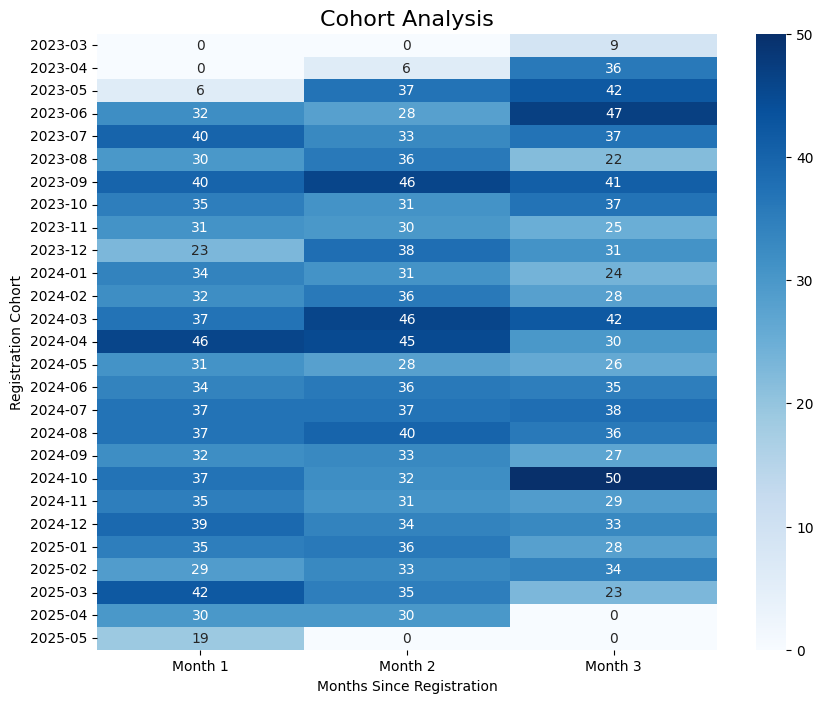

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(cohort_pivot, annot=True, fmt=".0f",cmap="Blues",cbar=True)
plt.title("Cohort Analysis",fontsize=16)
plt.xlabel("Months Since Registration")
plt.ylabel("Registration Cohort")
plt.show()